# Stage 28 — Warm-Start Analysis

Analyses warm-start M2 variants trained from the Stage 1 (seed=42, ep45) encoder.
Baseline numbers pulled from prior reports — no re-evaluation of old models.

| Model | Source |
|-------|--------|
| L2+L4 warmstart | `proto_seg_ct_l2l4_warmstart.pth` (this run) |
| L2+L3+L4 warmstart | `proto_seg_ct_l234_warmstart.pth` (next run) |

**Baselines (from reports):**

| Model | Val Dice | 3D Dice |
|-------|----------|---------|
| M4 (max) | — | 0.8407 |
| M4-attn noent | 0.7949 | 0.8416 |
| M4-attn wloss (Exp A) | 0.8203 | 0.8475 |
| M4-attn pruned Run1 (Exp B) | 0.8136 | 0.8290 |
| M2 cold-start | 0.8380 | 0.8722 |

## 0. Setup

In [2]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import MMWHSPatientDataset, LABEL_NAMES, NUM_CLASSES
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
DATA_DIR = "data/pack/processed_data"
MODALITY = "ct"
LOG_DIR = "results/v6"
CKPT_DIR = "checkpoints"
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

# Baselines from prior reports
BASELINES = {
    "M4 (max)": {"val": None, "3d": 0.8407},
    "M4-attn noent": {"val": 0.7949, "3d": 0.8416},
    "M4-attn wloss": {"val": 0.8203, "3d": 0.8475},
    "M4-attn pruned": {"val": 0.8136, "3d": 0.8290},
    "M2 cold-start": {"val": 0.8380, "3d": 0.8722},
}

print(f"Device: {DEVICE}")
print(f"Baselines loaded: {list(BASELINES.keys())}")

Device: mps
Baselines loaded: ['M4 (max)', 'M4-attn noent', 'M4-attn wloss', 'M4-attn pruned', 'M2 cold-start']


## 1. Load Checkpoints

In [3]:
import pathlib

WARMSTART_MODELS = {
    "L2+L4 warmstart": "proto_seg_ct_l2l4_warmstart.pth",
    "L2+L3+L4 warmstart": "proto_seg_ct_l234_warmstart.pth",
}

loaded = {}
for name, fname in WARMSTART_MODELS.items():
    path = f"{CKPT_DIR}/{fname}"
    if not pathlib.Path(path).exists():
        print(f"  ⬜ {name}: not yet trained ({fname})")
        continue
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    m = ProtoSegNet(
        n_classes=NUM_CLASSES,
        proto_levels=ckpt["proto_levels"],
        use_level_attention=ckpt.get("use_level_attention", False),
    ).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    loaded[name] = {"model": m, "ckpt": ckpt}
    print(
        f"  ✅ {name}: ep={ckpt['epoch']}  best_val={ckpt['best_val_dice']:.4f}  levels={ckpt['proto_levels']}"
    )

  ✅ L2+L4 warmstart: ep=65  best_val=0.8286  levels=[2, 4]
  ✅ L2+L3+L4 warmstart: ep=65  best_val=0.8191  levels=[2, 3, 4]


## 2. Training Curves

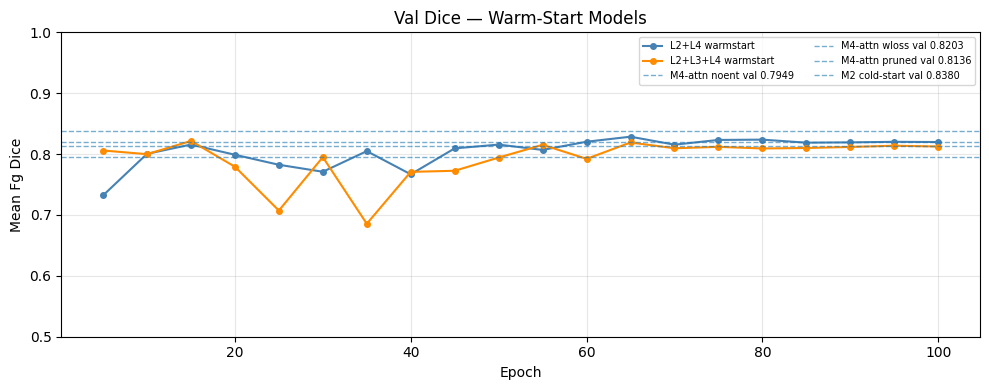

In [3]:
LOG_FILES = {
    "L2+L4 warmstart": f"{LOG_DIR}/train_curve_proto_ct_l2l4_warmstart.csv",
    "L2+L3+L4 warmstart": f"{LOG_DIR}/train_curve_proto_ct_l234_warmstart.csv",
}
COLORS = {"L2+L4 warmstart": "steelblue", "L2+L3+L4 warmstart": "darkorange"}

fig, ax = plt.subplots(figsize=(10, 4))
for name, log_path in LOG_FILES.items():
    if not pathlib.Path(log_path).exists():
        continue
    log = pd.read_csv(log_path)
    val = log.dropna(subset=["val_mean_fg_dice"])
    ax.plot(
        val["epoch"],
        val["val_mean_fg_dice"],
        "o-",
        ms=4,
        lw=1.5,
        color=COLORS[name],
        label=name,
    )

# Baselines
for bname, bvals in BASELINES.items():
    if bvals["val"]:
        ax.axhline(
            bvals["val"],
            ls="--",
            lw=1,
            alpha=0.6,
            label=f"{bname} val {bvals['val']:.4f}",
        )

ax.set(
    title="Val Dice — Warm-Start Models",
    xlabel="Epoch",
    ylabel="Mean Fg Dice",
    ylim=(0.5, 1.0),
)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{LOG_DIR}/train_curve_warmstart_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 3. 3D Dice Evaluation

In [ ]:
@torch.no_grad()
def eval_3d(model):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


warmstart_results = {}
for name, info in loaded.items():
    print(f"Evaluating {name}…", flush=True)
    res = eval_3d(info["model"])
    means = [mean_foreground_dice(d) for d in res.values()]
    overall = np.mean(means)
    warmstart_results[name] = {"per_patient": res, "mean": overall}

    print(f"  {name}: 3D Dice = {overall:.4f}")
    print(
        f"  {'Patient':<12} {'MeanFg':>7}  "
        + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES)
    )
    for pid, dice in sorted(res.items()):
        mfg = mean_foreground_dice(dice)
        vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
        print(f"  {pid:<12} {mfg:>7.4f}  {vals}")
    print()

Evaluating L2+L4 warmstart…
  L2+L4 warmstart: 3D Dice = 0.8291
  Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
  ct_1019       0.7219  0.696  0.870  0.584  0.865  0.711  0.771  0.557
  ct_1020       0.9362  0.892  0.966  0.940  0.916  0.928  0.972  0.938

Evaluating L2+L3+L4 warmstart…
  L2+L3+L4 warmstart: 3D Dice = 0.8635
  Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
  ct_1019       0.7985  0.803  0.909  0.695  0.878  0.736  0.820  0.748
  ct_1020       0.9284  0.887  0.955  0.936  0.910  0.918  0.974  0.919



## 4. Comparison Table

In [ ]:
M2_3D = 0.8722

rows = []
for bname, bvals in BASELINES.items():
    rows.append(
        {
            "Model": bname,
            "Levels": "—",
            "Val Dice": bvals["val"],
            "3D Dice": bvals["3d"],
        }
    )
for name, res in warmstart_results.items():
    ckpt = loaded[name]["ckpt"]
    levels = "+".join(f"L{l}" for l in ckpt["proto_levels"])
    rows.append(
        {
            "Model": f"{name} ←",
            "Levels": levels,
            "Val Dice": ckpt["best_val_dice"],
            "3D Dice": res["mean"],
        }
    )

df = pd.DataFrame(rows)
df["Δ vs M2"] = df["3D Dice"] - M2_3D
print(df.to_string(index=False, float_format="{:.4f}".format))

df.to_csv(f"{LOG_DIR}/comparison_table_warmstart.csv", index=False)
print(f"\nSaved: {LOG_DIR}/comparison_table_warmstart.csv")

               Model   Levels  Val Dice  3D Dice  Δ vs M2
            M4 (max)        —       NaN   0.8407  -0.0315
       M4-attn noent        —    0.7949   0.8416  -0.0306
       M4-attn wloss        —    0.8203   0.8475  -0.0247
      M4-attn pruned        —    0.8136   0.8290  -0.0432
       M2 cold-start        —    0.8380   0.8722   0.0000
   L2+L4 warmstart ←    L2+L4    0.8286   0.8291  -0.0431
L2+L3+L4 warmstart ← L2+L3+L4    0.8191   0.8635  -0.0087

Saved: results/v6/comparison_table_warmstart.csv


## 5. Per-Class Breakdown

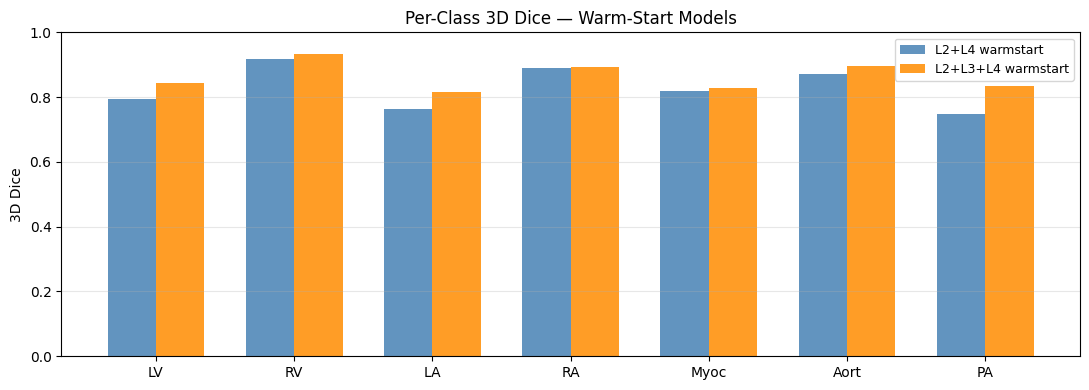

In [6]:
if warmstart_results:
    fig, ax = plt.subplots(figsize=(11, 4))
    x = np.arange(len(FG_NAMES))
    width = 0.35
    colors = list(COLORS.values())

    for i, (name, res) in enumerate(warmstart_results.items()):
        # Average per-class dice across patients
        per_class = {}
        for dice in res["per_patient"].values():
            for n in FG_NAMES:
                per_class.setdefault(n, []).append(dice.get(n, float("nan")))
        means = [np.nanmean(per_class[n]) for n in FG_NAMES]
        ax.bar(x + i * width, means, width, label=name, color=colors[i], alpha=0.85)

    ax.set_xticks(x + width / 2 * (len(warmstart_results) - 1))
    ax.set_xticklabels([n[:4] for n in FG_NAMES])
    ax.set_ylim(0, 1)
    ax.set_ylabel("3D Dice")
    ax.set_title("Per-Class 3D Dice — Warm-Start Models")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{LOG_DIR}/per_class_warmstart.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. RQ9 Verdict

In [ ]:
print("RQ9: Does warm-starting M2 with M4-attn encoder improve over cold-start M2?")
print(f"  M2 cold-start 3D Dice : {M2_3D:.4f}  (reference)")
print()
for name, res in warmstart_results.items():
    d = res["mean"]
    delta = d - M2_3D
    verdict = "✅ beats M2" if d > M2_3D else f"❌ below M2 ({delta:+.4f})"
    print(f"  {name}: {d:.4f}  {verdict}")

RQ9: Does warm-starting M2 with M4-attn encoder improve over cold-start M2?
  M2 cold-start 3D Dice : 0.8722  (reference)

  L2+L4 warmstart: 0.8291  ❌ below M2 (-0.0431)
  L2+L3+L4 warmstart: 0.8635  ❌ below M2 (-0.0087)


## 7. Prototype Quality Analysis

Metrics: **Purity** (class-selectivity), **AP** (spatial precision), **Compactness** (focus),
**Level Dominance** (pixel share per level).

Baseline proto quality values (from reports, L4 only for cross-model comparison):

| Model | Purity L4 | AP L4 | Compact. L4 | Dom. L4 |
|-------|-----------|-------|-------------|---------|
| M4 (max) | 0.824 | 0.189 | 0.573 | 4.3% |
| M4-attn noent | 0.537 | 0.085 | 0.494 | 12.5% |
| M4-attn wloss | 0.697 | 0.195 | 0.365 | 17.5% |
| M2 cold-start | 0.804 | 0.236 | 0.361 | 49.1% |

In [4]:
from src.data.mmwhs_dataset import MMWHSSliceDataset, make_dataloaders
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_per_level_ap,
    compute_level_dominance,
)

# Loaders for proto quality (train for purity, test for rest)
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
train_loader_pq = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader_pq = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

proto_quality = {}
for name, info in loaded.items():
    model = info["model"]
    levels = model.proto_levels
    print(f"\nComputing proto quality for {name}  levels={levels}…", flush=True)

    purity = compute_purity(model, train_loader_pq)
    compact = compute_compactness(model, test_loader_pq)
    ap = compute_per_level_ap(model, test_loader_pq)
    dom = compute_level_dominance(model, test_loader_pq)

    # Mean per level (foreground classes only)
    purity_l = purity.groupby("level")["purity"].mean()
    compact_l = compact.groupby("level")["compactness"].mean()
    ap_l = ap.groupby("level")["ap"].mean()

    summary = {}
    for l in levels:
        summary[l] = {
            "purity": purity_l.get(l, float("nan")),
            "ap": ap_l.get(l, float("nan")),
            "compactness": compact_l.get(l, float("nan")),
            "dominance": dom[f"frac_l{l}"].values[0]
            if f"frac_l{l}" in dom.columns
            else float("nan"),
        }
    proto_quality[name] = {
        "summary": summary,
        "purity_df": purity,
        "ap_df": ap,
        "compact_df": compact,
        "dom_df": dom,
    }

    print(f"  {'Level':<6} {'Purity':>7} {'AP':>7} {'Compact':>8} {'Dominance':>10}")
    print(
        f"  {'------':<6} {'-------':>7} {'-------':>7} {'--------':>8} {'----------':>10}"
    )
    for l in levels:
        s = summary[l]
        print(
            f"  L{l:<5} {s['purity']:>7.3f} {s['ap']:>7.3f} {s['compactness']:>8.3f} {s['dominance']:>9.1%}"
        )


Computing proto quality for L2+L4 warmstart  levels=[2, 4]…
  Level   Purity      AP  Compact  Dominance
  ------ ------- ------- -------- ----------
  L2       0.185   0.084    0.321     76.3%
  L4       0.546   0.226    0.482     23.7%

Computing proto quality for L2+L3+L4 warmstart  levels=[2, 3, 4]…
  Level   Purity      AP  Compact  Dominance
  ------ ------- ------- -------- ----------
  L2       0.160   0.035    0.333     74.0%
  L3       0.440   0.120    0.547     12.9%
  L4       0.709   0.138    0.546     13.0%


             Model Level  Purity    AP  Compactness Dominance
          M4 (max)    L4   0.824 0.189        0.573      4.3%
     M4-attn noent    L4   0.537 0.085        0.494     12.5%
     M4-attn wloss    L4   0.697 0.195        0.365     17.5%
     M2 cold-start    L4   0.804 0.236        0.361     49.1%
   L2+L4 warmstart    L2   0.185 0.084        0.321     76.3%
   L2+L4 warmstart    L4   0.546 0.226        0.482     23.7%
L2+L3+L4 warmstart    L2   0.160 0.035        0.333     74.0%
L2+L3+L4 warmstart    L3   0.440 0.120        0.547     12.9%
L2+L3+L4 warmstart    L4   0.709 0.138        0.546     13.0%


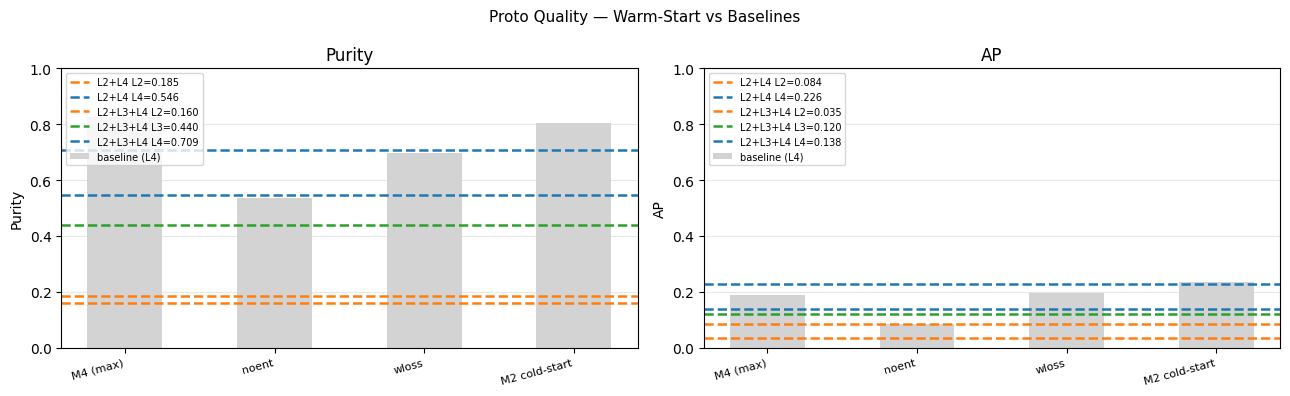

In [5]:
# ── Summary table vs baselines (L4 focus for cross-model comparison) ──────────
BASELINE_QUALITY = {
    "M4 (max)": {
        "purity": 0.824,
        "ap": 0.189,
        "compactness": 0.573,
        "dominance": 0.043,
    },
    "M4-attn noent": {
        "purity": 0.537,
        "ap": 0.085,
        "compactness": 0.494,
        "dominance": 0.125,
    },
    "M4-attn wloss": {
        "purity": 0.697,
        "ap": 0.195,
        "compactness": 0.365,
        "dominance": 0.175,
    },
    "M2 cold-start": {
        "purity": 0.804,
        "ap": 0.236,
        "compactness": 0.361,
        "dominance": 0.491,
    },
}

rows = []
for bname, bq in BASELINE_QUALITY.items():
    rows.append(
        {
            "Model": bname,
            "Level": "L4",
            "Purity": bq["purity"],
            "AP": bq["ap"],
            "Compactness": bq["compactness"],
            "Dominance": f"{bq['dominance']:.1%}",
        }
    )

for name, pq in proto_quality.items():
    for l, s in pq["summary"].items():
        rows.append(
            {
                "Model": f"{name}",
                "Level": f"L{l}",
                "Purity": s["purity"],
                "AP": s["ap"],
                "Compactness": s["compactness"],
                "Dominance": f"{s['dominance']:.1%}",
            }
        )

df_q = pd.DataFrame(rows)
print(df_q.to_string(index=False, float_format="{:.3f}".format))
df_q.to_csv(f"{LOG_DIR}/proto_quality_warmstart.csv", index=False)

# ── Purity & AP bar chart per level ──────────────────────────────────────────
if proto_quality:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    metric_cols = [("Purity", "purity"), ("AP", "ap")]

    for ax, (title, col) in zip(axes, metric_cols):
        # Baselines (L4 only)
        bl_names = list(BASELINE_QUALITY.keys())
        bl_vals = [BASELINE_QUALITY[b][col] for b in bl_names]
        x = np.arange(len(bl_names))
        ax.bar(x, bl_vals, 0.5, color="lightgray", label="baseline (L4)", zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [n.replace("M4-attn ", "") for n in bl_names],
            rotation=15,
            ha="right",
            fontsize=8,
        )

        # Warm-start models — one bar per active level
        level_colors = {2: "#ff7f0e", 3: "#2ca02c", 4: "#1f77b4"}
        for name, pq in proto_quality.items():
            short = name.replace(" warmstart", "")
            for l, s in pq["summary"].items():
                ax.axhline(
                    s[col],
                    color=level_colors.get(l, "purple"),
                    lw=1.8,
                    ls="--",
                    label=f"{short} L{l}={s[col]:.3f}",
                )

        ax.set_title(title)
        ax.set_ylabel(title)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Proto Quality — Warm-Start vs Baselines", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{LOG_DIR}/proto_quality_warmstart.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Effective Quality (Dominance-Weighted Aggregate)

Per-level metrics are hard to compare across models with different level sets.
**Effective quality** weights each level's score by its pixel dominance fraction:

```
effective_purity = Σ_l  frac_l × mean_fg_purity_l
```

A model where L2 dominates 76% of pixels will be penalised for L2's poor purity,
regardless of how good L4 looks in isolation.

In [6]:
from src.metrics.proto_quality import compute_effective_quality

# ── Compute effective quality for each warm-start model ──────────────────────
eff_rows = []
for name, pq in proto_quality.items():
    eff = compute_effective_quality(
        pq["purity_df"],
        pq["ap_df"],
        pq["compact_df"],
        pq["dom_df"],
    )
    eff_rows.append({"Model": name, **eff.iloc[0].to_dict()})

df_eff = pd.DataFrame(eff_rows)

# ── Baseline rows (L4-only data from reports — treated as single-level models) ─
# For M4 and M4-attn variants only L4 quality was tracked; dominance fractions
# are from reports. M2 cold-start has L3+L4 but L3 quality was not measured here.
BASELINE_EFF = {
    "M4 (max)": {
        "eff_p": 0.824 * 0.043,
        "eff_ap": 0.189 * 0.043,
        "note": "L4 only (4.3% dom)",
    },
    "M4-attn noent": {
        "eff_p": 0.537 * 0.125,
        "eff_ap": 0.085 * 0.125,
        "note": "L4 only (12.5% dom)",
    },
    "M4-attn wloss": {
        "eff_p": 0.697 * 0.175,
        "eff_ap": 0.195 * 0.175,
        "note": "L4 only (17.5% dom)",
    },
    "M2 cold-start": {
        "eff_p": 0.804 * 0.491,
        "eff_ap": 0.236 * 0.491,
        "note": "L4 only (49.1% dom) — L3 not measured",
    },
}
# Note: baseline eff_p values are LOWER BOUNDS — they only include the L4
# contribution. The true effective quality also includes L3 (and L1/L2 for M4
# variants), so baselines are listed for reference only.

print(
    "Effective Quality — Warm-Start Models vs Baselines (L4 contribution only for baselines)"
)
print()
print(f"  {'Model':<28} {'Eff. Purity':>11} {'Eff. AP':>8} {'Note'}")
print(f"  {'-' * 28} {'-' * 11} {'-' * 8} {'-' * 40}")
for bname, bv in BASELINE_EFF.items():
    print(f"  {bname:<28} {bv['eff_p']:>11.3f} {bv['eff_ap']:>8.3f}   {bv['note']}")
print()
for _, row in df_eff.iterrows():
    levels = [int(k.split("_l")[1]) for k in row.index if k.startswith("weight_l")]
    breakdown = "  ".join(
        f"L{l}: {row[f'purity_l{l}']:.3f}×{row[f'weight_l{l}']:.1%}"
        for l in sorted(levels)
    )
    print(
        f"  {row['Model']:<28} {row['effective_purity']:>11.3f} {row['effective_ap']:>8.3f}   ({breakdown})"
    )

# ── Save ──────────────────────────────────────────────────────────────────────
df_eff.to_csv(f"{LOG_DIR}/effective_quality_warmstart.csv", index=False)
print(f"\nSaved: {LOG_DIR}/effective_quality_warmstart.csv")

Effective Quality — Warm-Start Models vs Baselines (L4 contribution only for baselines)

  Model                        Eff. Purity  Eff. AP Note
  ---------------------------- ----------- -------- ----------------------------------------
  M4 (max)                           0.035    0.008   L4 only (4.3% dom)
  M4-attn noent                      0.067    0.011   L4 only (12.5% dom)
  M4-attn wloss                      0.122    0.034   L4 only (17.5% dom)
  M2 cold-start                      0.395    0.116   L4 only (49.1% dom) — L3 not measured

  L2+L4 warmstart                    0.270    0.118   (L2: 0.185×76.3%  L3: nan×nan%  L4: 0.546×23.7%)
  L2+L3+L4 warmstart                 0.268    0.059   (L2: 0.160×74.0%  L3: 0.440×12.9%  L4: 0.709×13.0%)

Saved: results/v6/effective_quality_warmstart.csv


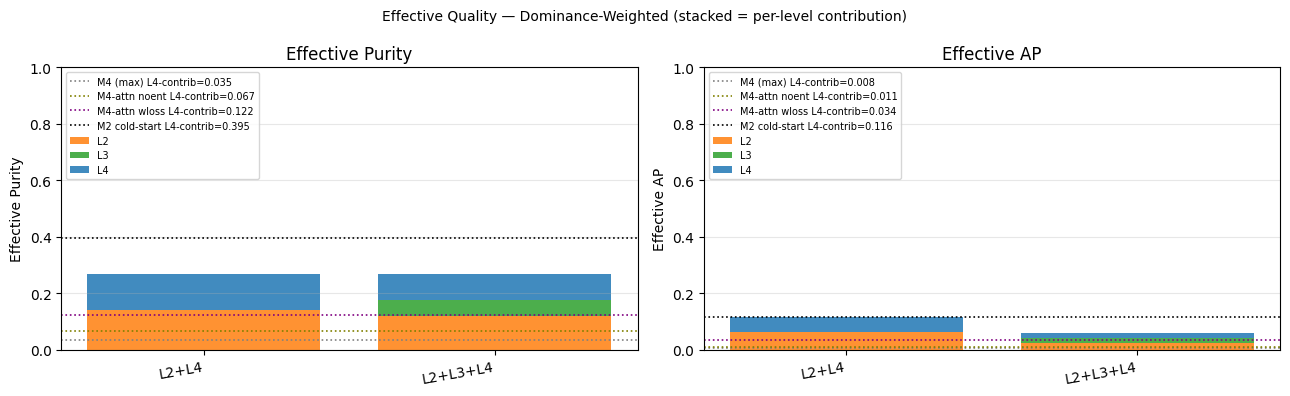

In [7]:
# ── Stacked bar: per-level contribution to effective purity ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
level_colors = {1: "#d62728", 2: "#ff7f0e", 3: "#2ca02c", 4: "#1f77b4"}
metrics = [("Effective Purity", "purity"), ("Effective AP", "ap")]

for ax, (title, metric) in zip(axes, metrics):
    x = np.arange(len(df_eff))
    bottoms = np.zeros(len(df_eff))

    for l in [1, 2, 3, 4]:
        col_w = f"weight_l{l}"
        col_m = f"{metric}_l{l}"
        if col_w not in df_eff.columns:
            continue
        heights = (df_eff[col_w] * df_eff[col_m]).fillna(0).values
        ax.bar(
            x, heights, bottom=bottoms, color=level_colors[l], label=f"L{l}", alpha=0.85
        )
        bottoms += heights

    # Baseline reference lines (L4 contribution only — lower bound)
    bl_colors = {
        "M4 (max)": "gray",
        "M4-attn noent": "olive",
        "M4-attn wloss": "purple",
        "M2 cold-start": "black",
    }
    for bname, bv in BASELINE_EFF.items():
        val = bv[f"eff_{metric[0]}"] if metric == "purity" else bv["eff_ap"]
        ax.axhline(
            val,
            ls=":",
            lw=1.2,
            color=bl_colors[bname],
            label=f"{bname} L4-contrib={val:.3f}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [n.replace(" warmstart", "") for n in df_eff["Model"]], rotation=10, ha="right"
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Effective Quality — Dominance-Weighted (stacked = per-level contribution)",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/effective_quality_warmstart.png", dpi=150, bbox_inches="tight")
plt.show()